# **EMPLOYEE RETENTION PREDICTION**

##  Project Overview
This project focuses on predicting employee retention using a dataset containing demographic, educational, and professional details of enrollees. The target variable indicates whether an employee is likely to stay (`0`) or leave (`1`). By analyzing these features, the goal is to build a robust machine learning pipeline that can help organizations identify employees at risk of attrition.

### **Importing libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

### **Loading the dataset**

In [2]:
train = pd.read_csv("aug_train.csv")
test = pd.read_csv("aug_test.csv")


In [3]:
display(train.head())
display(test.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,Oct-49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


##  Description


- **enrollee_id**: Unique identifier for each enrollee  
- **city**: City code where the enrollee resides  
- **city_development_index**: Development index of the city (higher = more developed)  
- **gender**: Gender of the enrollee  
- **relevent_experience**: Whether the enrollee has relevant work experience  
- **enrolled_university**: Enrollment status in university (e.g., full-time, part-time, none)  
- **education_level**: Highest education level attained  
- **major_discipline**: Field of study (e.g., STEM, Business)  
- **experience**: Total years of professional experience  
- **company_size**: Size of the last company worked at  
- **company_type**: Type of company (e.g., Pvt Ltd, Funded Startup)  
- **last_new_job**: Time since last job change  
- **training_hours**: Number of training hours completed  
- **target**: Binary label (0 = employee retained, 1 = employee left)

### **Data preprocessing**

In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (19158, 14)
Test shape: (2129, 13)


In [6]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [7]:
train.describe()
test.describe()

,enrollee_id,city_development_index,training_hours
count,2129.000000,2129.000000,2129.000000
mean,16861.614843,0.824984,64.983091
std,9576.846029,0.125074,60.238660
min,3.000000,0.448000,1.000000
25%,8562.000000,0.698000,23.000000
50%,16816.000000,0.903000,47.000000
75%,25129.000000,0.920000,86.000000
max,33353.000000,0.949000,334.000000


In [8]:
train.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [9]:
test.isnull().sum()

enrollee_id                 0
city                        0
city_development_index      0
gender                    508
relevent_experience         0
enrolled_university        31
education_level            52
major_discipline          312
experience                  5
company_size              622
company_type              634
last_new_job               40
training_hours              0
dtype: int64

In [10]:
def clean_experience(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x == '<1': return 0
    if x == '>20': return 21
    # sometimes there are values like '10+' in test - map to 10
    if x.endswith('+'):
        try:
            return int(x[:-1])
        except:
            return np.nan
    try:
        return int(x)
    except:
        return np.nan

def clean_last_new_job(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x == 'never': return 0
    if x == '>4': return 5
    try:
        return int(x)
    except:
        return np.nan

In [11]:
# Columns considered categorical (fillna with 'Unknown')
cat_cols = ['gender','enrolled_university','education_level',
            'major_discipline','company_size','company_type','relevent_experience']

for c in cat_cols:
    train[c] = train[c].fillna("Unknown")
    test[c]  = test[c].fillna("Unknown")   

# Clean numeric- string columns
train['experience'] = train['experience'].apply(clean_experience)
train['experience'] = train['experience'].fillna(train['experience'].median())

train['last_new_job'] = train['last_new_job'].apply(clean_last_new_job)
train['last_new_job'] = train['last_new_job'].fillna(train['last_new_job'].median())

test['experience'] = test['experience'].apply(clean_experience)
test['experience'] = test['experience'].fillna(test['experience'].median())

# For test 'last_new_job' sometimes absent; fill with mode or median if exists
if 'last_new_job' in test.columns:
    test['last_new_job'] = test['last_new_job'].apply(clean_last_new_job)
    if test['last_new_job'].isna().sum() > 0:
        test['last_new_job'] = test['last_new_job'].fillna(train['last_new_job'].median())

#### Statistical analysis after cleaning the dataset

In [22]:
train.describe()
test.describe()

,city_development_index,experience,last_new_job,training_hours,__is_train
count,2129.000000,2129.000000,2129.000000,2129.000000,2129.0
mean,0.824984,10.102395,1.995303,64.983091,0.0
std,0.125074,6.859207,1.642646,60.238660,0.0
min,0.448000,0.000000,0.000000,1.000000,0.0
25%,0.698000,4.000000,1.000000,23.000000,0.0
50%,0.903000,9.000000,1.000000,47.000000,0.0
75%,0.920000,16.000000,3.000000,86.000000,0.0
max,0.949000,21.000000,5.000000,334.000000,0.0


### **Exploratory data analysis**

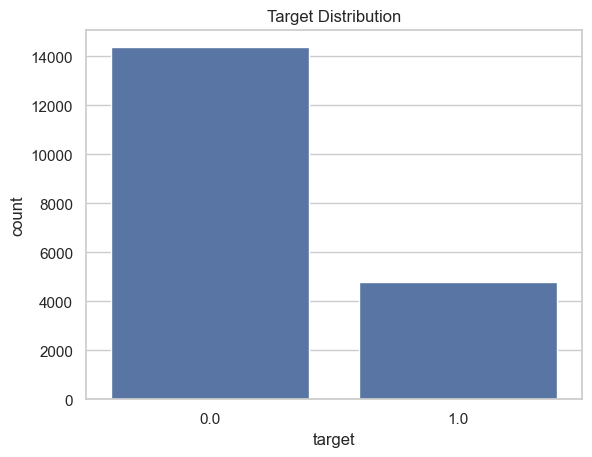

In [14]:
#Target variable analysis
sns.countplot(x='target', data=train)
plt.title("Target Distribution")
plt.show()

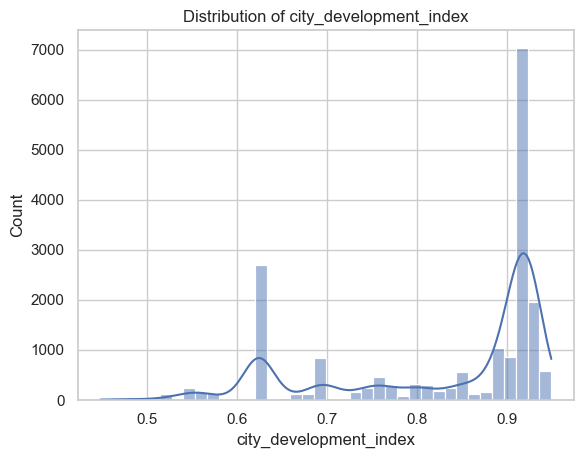

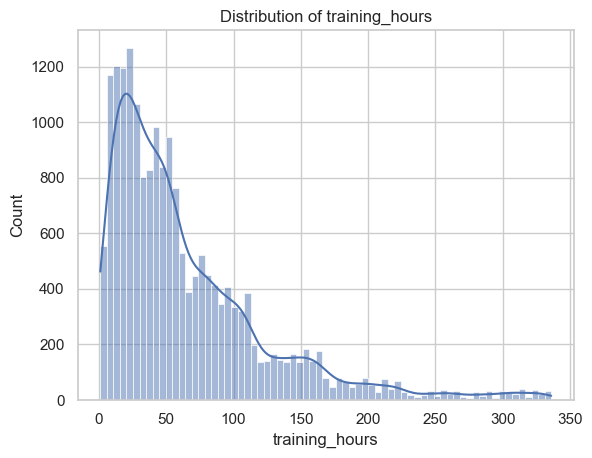

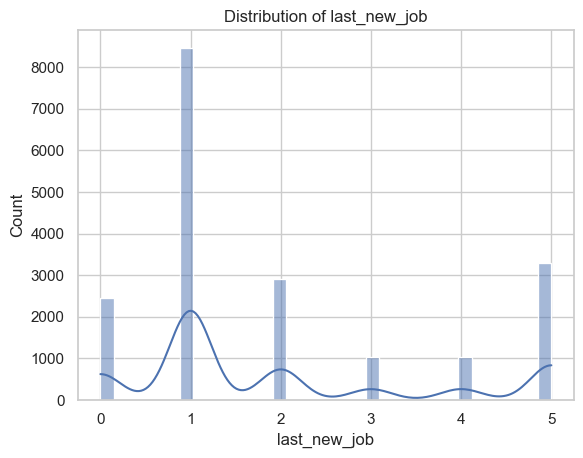

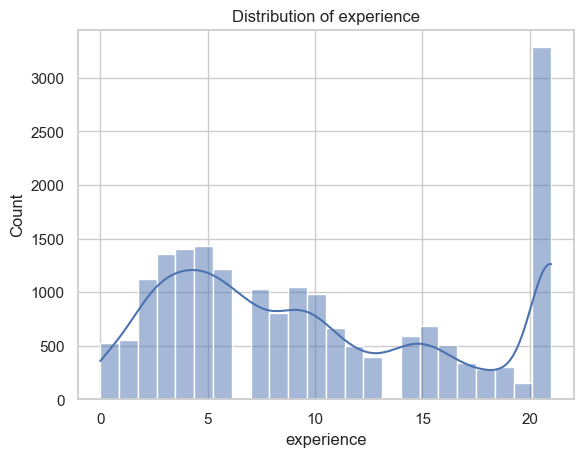

In [15]:
#Univariate Analysis- analyzing 1 col at a time to understand:Its distribution,Its spread,Outliers,Skewness,Patterns
num_cols = ['city_development_index', 'training_hours','last_new_job','experience']
for col in num_cols:
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

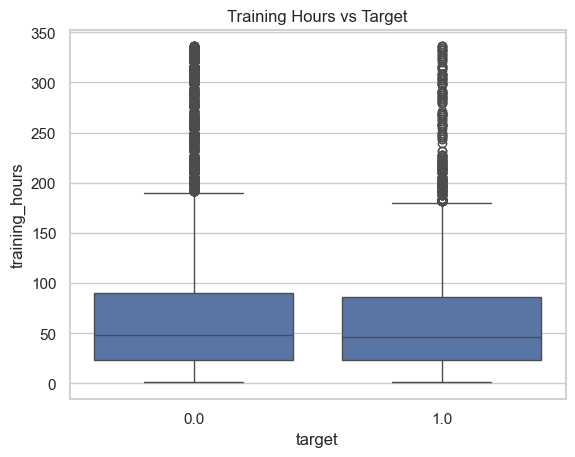

In [16]:
#Bivariate Analysis
sns.boxplot(x="target", y="training_hours", data=train)
plt.title("Training Hours vs Target")
plt.show()

#### What we learn from the above bivariate analysis is :
Training hours do not strongly differ between employees who stay vs. leave.
This feature is not a strong predictor for your ML models.
Models like Logistic Regression & RandomForest will pick up this weakness.

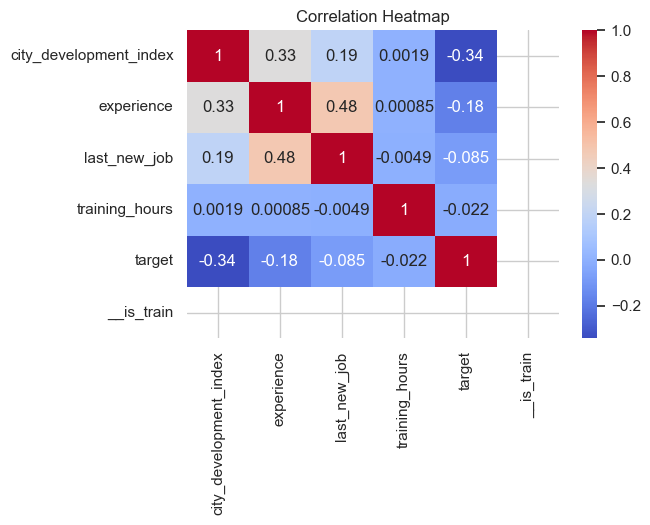

In [17]:
#correlation heat map (+1.0 → strong positive correlation,-1.0 → strong negative correlation,0 → no linear relationship)
#why correlation helps us: Detect which features may be useful in models,Understand relationships inside your data,Identify multicollinearity (not a big issue here))
plt.figure(figsize=(6,4))
sns.heatmap(train.select_dtypes(include=['float64','int64']).corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### **Feature Engineering**

In [12]:
cols_to_drop = ['enrollee_id', 'city', 'company_type', 'company_size', 'gender']

train = train.drop(cols_to_drop, axis=1)
test  = test.drop(cols_to_drop, axis=1)

In [13]:
# combine for encoding consistency
train['__is_train'] = 1
test['__is_train']  = 0 #to split the merged dataset back into train and test after encoding.
#In the train dataset, the column __is_train is set to 1 for every row.
#In the test dataset, the column __is_train is set to 0 for every row.

combined = pd.concat([train, test], axis=0).reset_index(drop=True)

In [18]:
# map relevent_experience and ensure target exists for combined
combined['relevent_experience'] = combined['relevent_experience'].map({
    'Has relevent experience': 1,
    'No relevent experience': 0,
    'Unknown': 0,  # treat unknown as 0 
    '0': 0,
    '1': 1
})

# Ensure target exists in combined (test target will be NaN)
if 'target' not in combined.columns:
    combined['target'] = np.nan

In [19]:
# one-hot encode (categorical)
ohe_cols = ['major_discipline',
            'enrolled_university','education_level']

# Fill any remaining NaN in these columns with 'Unknown' 
for c in ohe_cols:
    combined[c] = combined[c].fillna('Unknown')

In [20]:
# one-hot encode
combined_encoded = pd.get_dummies(combined, columns=ohe_cols, drop_first=True)

# Remove characters
combined_encoded.columns = combined_encoded.columns.str.replace(r'[\[\]<>]', '', regex=True)

In [21]:
# split back
train_encoded = combined_encoded[combined_encoded['__is_train'] == 1].copy()
test_encoded  = combined_encoded[combined_encoded['__is_train'] == 0].copy()

# Drop helper column
train_encoded.drop(columns='__is_train', inplace=True)
test_encoded.drop(columns='__is_train', inplace=True)

###### After encoding the combined dataset, I separated the data back into training and testing sets using a helper column __is_train. This ensured consistent encoding. Finally, I removed the helper column as it is not a real feature.

In [23]:
# Create X, y
X = train_encoded.drop(['target'], axis=1)
y = train_encoded['target']
X_test_final = test_encoded.drop(['target'], axis=1, errors='ignore')
#X_test_final contains only model input features for predicting the test dataset.

##### 
* X contains only the independent features used to train the model
* y becomes the dependent variable in integer format
* X_test_final contains only model input features for predicting the test dataset

### **Train-test split**

In [24]:
# split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (15326, 19)
X_val shape: (3832, 19)


#### SMOTE balances your dataset so the model learns BOTH classes equally and predicts resignations more accurately.

In [25]:
# Assuming target column 
train['target'].value_counts()
train['target'].value_counts(normalize=True)  # gives percentages

target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64

#### Before SMOTE there is class imbalance ,the class distribution is 75% ,25% 

In [26]:
#  SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE class dist:", np.bincount(y_train_sm))

After SMOTE class dist: [11501 11501]


In [27]:
# scaling for LR and SVM (fit scaler on SMOTE data )
scaler = StandardScaler()
scaler.fit(X_train_sm)   # fit on training distribution 
X_train_sm_scaled = scaler.transform(X_train_sm)
X_val_scaled = scaler.transform(X_val)

### **Model training and evaluation**

In [28]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_sm_scaled, y_train_sm)
y_pred_lr = lr.predict(X_val_scaled)

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

Logistic Regression Accuracy: 0.7038100208768268
              precision    recall  f1-score   support

         0.0       0.84      0.74      0.79      2880
         1.0       0.43      0.58      0.49       952

    accuracy                           0.70      3832
   macro avg       0.64      0.66      0.64      3832
weighted avg       0.74      0.70      0.72      3832



In [30]:
# SVM 
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_sm_scaled, y_train_sm)
y_pred_svm = svm.predict(X_val_scaled)

In [31]:
print("SVM Accuracy:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

SVM Accuracy: 0.7132045929018789
              precision    recall  f1-score   support

         0.0       0.85      0.76      0.80      2880
         1.0       0.44      0.59      0.50       952

    accuracy                           0.71      3832
   macro avg       0.64      0.67      0.65      3832
weighted avg       0.75      0.71      0.73      3832



In [32]:
#RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_val)

In [33]:
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Random Forest Accuracy: 0.7278183716075156
              precision    recall  f1-score   support

         0.0       0.85      0.78      0.81      2880
         1.0       0.46      0.58      0.51       952

    accuracy                           0.73      3832
   macro avg       0.65      0.68      0.66      3832
weighted avg       0.75      0.73      0.74      3832



In [34]:
#XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                    random_state=42,
                   )


xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_val)

In [35]:
print("XGBoost Accuracy:", accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

XGBoost Accuracy: 0.7510438413361169
              precision    recall  f1-score   support

         0.0       0.84      0.83      0.83      2880
         1.0       0.50      0.51      0.50       952

    accuracy                           0.75      3832
   macro avg       0.67      0.67      0.67      3832
weighted avg       0.75      0.75      0.75      3832



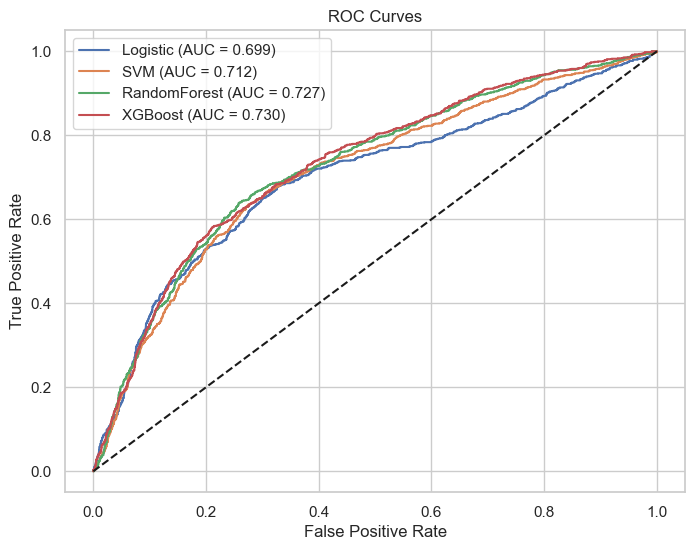

In [36]:
#  ROC curves
models_proba = {
    'Logistic': (lr, X_val_scaled),
    'SVM': (svm, X_val_scaled),
    'RandomForest': (rf, X_val),
    'XGBoost': (xgb, X_val)
}

plt.figure(figsize=(8,6))

for name, (model, Xinput) in models_proba.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(Xinput)[:,1]
    else:
        probs = model.decision_function(Xinput)
        probs = (probs - probs.min())/(probs.max()-probs.min()+1e-9)  # normalize for plotting

    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

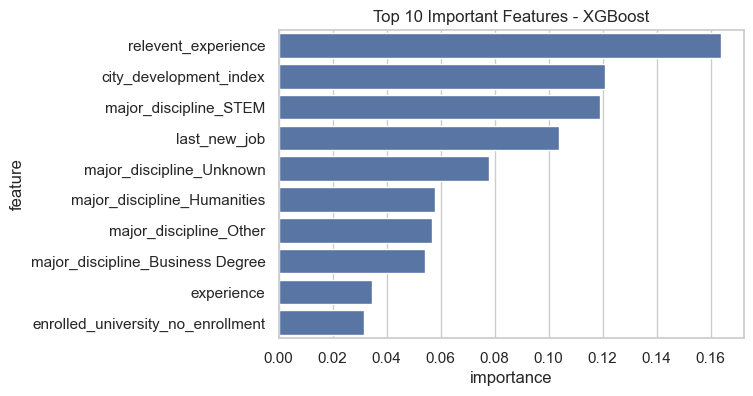

Top 10 Important Features (XGBoost):


,feature,importance
1,relevent_experience,0.164009
0,city_development_index,0.120815
9,major_discipline_STEM,0.119202
3,last_new_job,0.103665
10,major_discipline_Unknown,0.077911
6,major_discipline_Humanities,0.057774
8,major_discipline_Other,0.056840
5,major_discipline_Business Degree,0.054314
2,experience,0.034703
13,enrolled_university_no_enrollment,0.031604


In [37]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=xgb_importance.head(10), x='importance', y='feature')
plt.title("Top 10 Important Features - XGBoost")
plt.show()

print("Top 10 Important Features (XGBoost):")
display(xgb_importance.head(10))
